# PANDAPROSUMER EXAMPLE: Energy System

## DESCRIPTION:
This example demonstrates how to create a single supervisor controller in pandaprosumer and use it to manage the parameters of other controllers within a prosumer. In this example, the supervisor controls a heat pump and a gas boiler.
 If the gas price is very low, the gas boiler is prioritized. If the gas price is not low, the heat pump is prioritized. If the gas price is extremely high, the gas boiler is turned off—even if the heat pump cannot meet the full demand. The demand and source temperature data is read from an Excel file and stored in pandas dataframe. It includes the information about the power required by the consumer and source temperature at each time step.


![title](img/energy_system.png)

## Glossary:
- Network: A configuration of connected energy generators and energy consumers
- Element: A single energy generator or a single energy consumer
- Controller: The logic of an element that defines its behaviour and its limits
- Prosumer/Container: A pandaprosumer data structure that holds data related to elements and their controllers.
- Const Profile Controller: The initial controller in the network that interacts with other element controllers; it also manages external data via time series.
- Supervisor: A controller that can modify the parameters of other controllers and elements within the prosumer during the calculation process.
- Map / mapping: A connection between two controllers that specifies what information is exchanged between the corresponding elements.

## Network design philosophy:
In pandaprosumer, a system's component is represented by a network element. Each element is assigned a container and its own element controller. A container is a structure that contains the component's configuration data (static input data), which can include information that will not change in the analysis such as size, nominal power, efficiency, etc. The behaviour of an element is governed by its controller. Connections between elements are defined in maps, which couple output parameters of one controller to the input parameter of a controller of a connected element. The network is managed by a controller called ConstProfileController. This controller is connected to all element controllers and manages dynamic input data from external sources (e.g. Excel file). For each time step it distributes the dynamic input data to the relevant element controllers.

# 1 - INPUT DATA:
First let's import libraries required for data management.

In [300]:
import pandapower
from pandapower.timeseries import OutputWriter

from pandaprosumer.create_controlled import *
from pandaprosumer.energy_system import create_empty_energy_system, add_net_to_energy_system, \
    add_pandaprosumer_to_energy_system
from pandaprosumer.energy_system.control.controller.coupling.network_coupling import NetworkCouplingControl
from pandaprosumer.energy_system.control.controller.data_model.network_coupling import NetworkCouplingData
from pandaprosumer.energy_system.timeseries.run_time_series_energy_system import \
    run_timeseries as run_time_series_system
from pandaprosumer.mapping import GenericMapping, FluidMixMapping, FluidMixEnergySystemMapping, \
    GenericEnergySystemMapping

We define the analysis time series.

In [301]:
start = '2020-01-01 00:00:00'
time_resolution_s = 900

Now we import our demand data and transform it into an appropriate DFData object. All data of an individual element is stored in a dedicated DFData object.

In [302]:
import sys
import os

current_directory = os.getcwd()
parent_directory = os.path.dirname(current_directory)
sys.path.append(parent_directory)

demand_data = pd.read_excel('data/energy_system.xlsx')

end = pd.Timestamp(start) + len(demand_data) * pd.Timedelta(f"00:00:{time_resolution_s}") - pd.Timedelta("00:00:01")

dur = pd.date_range(start=start, end=end, freq='900s', tz='utc')
demand_data.index = dur
demand_input = DFData(demand_data)
print(demand_input.df.head(10))

                           Tin_cond  Tout_cond  Mass-flow-cond  Tin,evap  \
2020-01-01 00:00:00+00:00      20.7       75.7             2.0      10.0   
2020-01-01 00:15:00+00:00      17.2       71.4             2.2      10.7   
2020-01-01 00:30:00+00:00      19.4       70.0             2.5      12.0   
2020-01-01 00:45:00+00:00      20.6       67.6             2.6      11.0   
2020-01-01 01:00:00+00:00      18.8       74.0             2.3      11.5   
2020-01-01 01:15:00+00:00      19.6       67.4             2.1       9.5   
2020-01-01 01:30:00+00:00      18.6       69.0             2.0       9.0   
2020-01-01 01:45:00+00:00      18.7       73.6             1.9      10.0   
2020-01-01 02:00:00+00:00      20.7       67.7             2.0      11.0   
2020-01-01 02:15:00+00:00      18.7       73.5             2.3      13.0   

                           demand_1  demand_2  demand_3  demand_4  
2020-01-01 00:00:00+00:00       100    100.01    100.02        10  
2020-01-01 00:15:00+00:00  

We can plot the evolution of the demand from the Excel file.

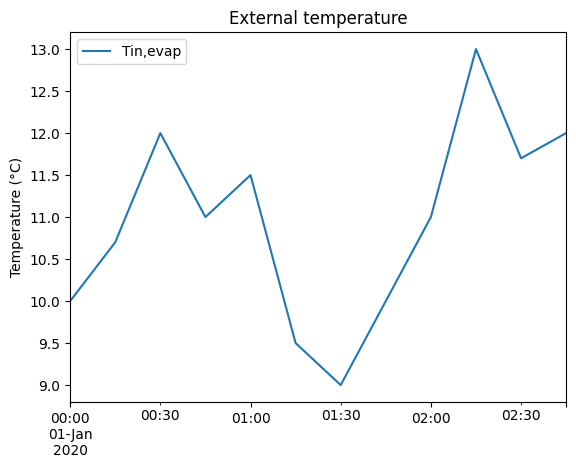

In [303]:
import matplotlib.pyplot as plt

demand_input.df.plot(y='Tin,evap')
plt.title("External temperature")
plt.ylabel("Temperature (°C)")
plt.show()

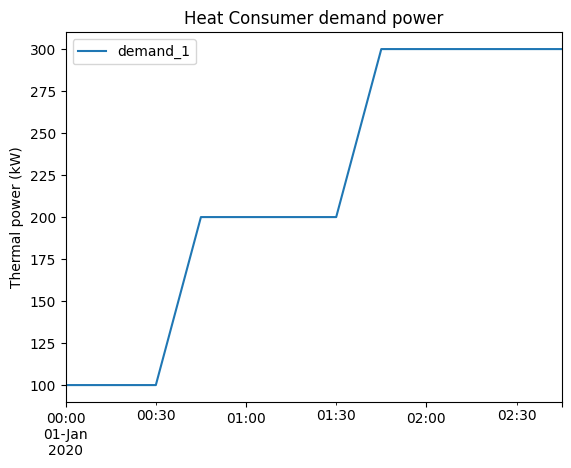

In [304]:
demand_input.df.plot(y='demand_1')
plt.title("Heat Consumer demand power")
plt.ylabel("Thermal power (kW)")
plt.show()

# 2 - CREATING ELEMENTS OF THE NETWORK:
In this example, the network is made up of four elements: a supervisor, two source and a consumer. The source is represented by a heat pump or a gas boiler and the consumer is modelled by a single heat demand element.

We begin by defining an empty prosumer container object and then add the different elements and their respective controllers to it.

In [305]:
def _create_pipes_network():
    net = pandapipes.create_empty_network(fluid="water", name='net_pipes')
    t_amb_k = 293
    pandapipes.set_user_pf_options(net, ambient_temperature=t_amb_k, mode='bidirectional')

    # Create junctions
    j0 = pandapipes.create_junction(net, pn_bar=10, tfluid_k=350, geodata=(0, 1))
    j1 = pandapipes.create_junction(net, pn_bar=10, tfluid_k=350, geodata=(2, 1))
    j2 = pandapipes.create_junction(net, pn_bar=10, tfluid_k=350, geodata=(2, 0))
    j3 = pandapipes.create_junction(net, pn_bar=10, tfluid_k=350, geodata=(0, 0))

    # Create branched elements
    pandapipes.create_pipes_from_parameters(net, from_junctions=[j0, j2], to_junctions=[j1, j3], length_km=0.1,
                                            diameter_m=0.05, u_w_per_m2k=10, text_k=t_amb_k)

    pandapipes.create_circ_pump_const_pressure(net,
                                               j3,
                                               j0,
                                               p_flow_bar=10,
                                               plift_bar=5,
                                               t_flow_k=350)

    pandapipes.create_heat_consumer(net, from_junction=j1, to_junction=j2,
                                    qext_w=100e3, controlled_mdot_kg_per_s=3)

    return net

In [306]:
def _create_power_network():
    net = pandapower.create_empty_network(name='net_power')
    b1 = pandapower.create_bus(net, vn_kv=20.)
    b2 = pandapower.create_bus(net, vn_kv=20.)
    pandapower.create_line(net, from_bus=b1, to_bus=b2, length_km=2.5, std_type="NAYY 4x50 SE")
    pandapower.create_ext_grid(net, bus=b1)
    pandapower.create_load(net, bus=b2, p_mw=1.)
    return net

In [307]:
def _create_prosumer_prod(hp_level):
    prosumer = create_empty_prosumer_container(name='prosumer_prod', check_order=False)
    data_source = demand_input
    period = create_period(prosumer, time_resolution_s, start, end, 'utc', 'default')

    cp_input_columns = ["Tin,evap"]
    cp_result_columns = ["Tin,evap"]

    hp_params = {'carnot_efficiency': 0.5,
                 'pinch_c': 5,
                 'delta_t_evap_c': 8,
                 'max_p_comp_kw': 1000e3}

    cp_controller_index = create_controlled_const_profile(prosumer, cp_input_columns, cp_result_columns,
                                                          data_source, period, 0, 0)

    hp_controller_index = create_controlled_heat_pump(prosumer, period=period, name='hp_controller',
                                                      level=hp_level, order=0, **hp_params)
    GenericMapping(container=prosumer,
                   initiator_id=cp_controller_index,
                   initiator_column="Tin,evap",
                   responder_id=hp_controller_index,
                   responder_column="t_evap_in_c",
                   order=0)

    return prosumer

In [308]:
def _create_prosumer_dmd(level):
    prosumer = create_empty_prosumer_container(name='prosumer_dmd', check_order=False)
    data_source = demand_input
    period = create_period(prosumer, time_resolution_s, start, end, 'utc', 'default')

    cp_input_columns = ["demand_1"]
    cp_result_columns = ["demand_kw"]

    hx_params = {'t_1_in_nom_c': 45,
                 't_1_out_nom_c': 30,
                 't_2_in_nom_c': 20,
                 't_2_out_nom_c': 40,
                 'mdot_2_nom_kg_per_s': 3.58}

    hd_params = {'t_in_set_c': 40,
                 't_out_set_c': 20}

    cp_controller_index = create_controlled_const_profile(prosumer, cp_input_columns, cp_result_columns,
                                                          data_source, period, 0, 0)

    hx_controller_index = create_controlled_heat_exchanger(prosumer, period=period, name='hx_controller',
                                                           level=level, order=0, **hx_params)
    hd_controller_index = create_controlled_heat_demand(prosumer, period=period, name='hd_controller',
                                                        level=level, order=1, **hd_params)

    GenericMapping(container=prosumer,
                   initiator_id=cp_controller_index,
                   initiator_column="demand_kw",
                   responder_id=hd_controller_index,
                   responder_column="q_demand_kw",
                   order=0)

    FluidMixMapping(container=prosumer,
                    initiator_id=hx_controller_index,
                    responder_id=hd_controller_index,
                    order=0)

    return prosumer

In [309]:
def _create_energy_system(nets, prosumers, name="test_energy_system"):
    energy_system = create_empty_energy_system(name=name)
    sample_prosumer_period = prosumers[0].period
    create_period(energy_system, sample_prosumer_period.iloc[0]["resolution_s"],
                  sample_prosumer_period.iloc[0]["start"],
                  sample_prosumer_period.iloc[0]["end"],
                  timezone=sample_prosumer_period.iloc[0]["timezone"],
                  name=sample_prosumer_period.iloc[0]["name"])
    for net in nets:
        add_net_to_energy_system(energy_system, net, net_name=net.name)
    for prosumer in prosumers:
        add_pandaprosumer_to_energy_system(energy_system, prosumer, pandaprosumer_name=prosumer.name)
    return energy_system

In [310]:
net = _create_pipes_network()
net_power = _create_power_network()
prosumer_prod = _create_prosumer_prod(hp_level=2)
prosumer_dmd = _create_prosumer_dmd(level=3)
energy_system = _create_energy_system([net, net_power], [prosumer_prod, prosumer_dmd])

# 4 - CREATING CONNECTIONS (MAPS) BETWEEN THE CONTROLLERS:
Network configuration

For each controller we define how it is connected to other controllers.



In [311]:
def create_controlled_network_coupling(net,
                                       element_index,
                                       element_name='heat_consumer',
                                       input_columns=[],
                                       result_columns=[],
                                       temp_fluid_map_input_col=[],
                                       mdot_fluid_map_input_col=[],
                                       temp_fluid_map_output_idx=None,
                                       mdot_fluid_map_output_idx=None,
                                       level=0,
                                       order=0):
    if isinstance(element_index, (np.integer, int)):
        element_index = [int(element_index)]
    elif isinstance(element_index, np.ndarray):
        element_index = [int(i) for i in element_index.tolist()]
    elif isinstance(element_index, list):
        element_index = [int(i) for i in element_index]

    networkcoupling = NetworkCouplingData(element_index=element_index,
                                          element_name=element_name,
                                          input_columns=input_columns,
                                          result_columns=result_columns)

    n = NetworkCouplingControl(net,
                               networkcoupling,
                               temp_fluid_map_input_col=temp_fluid_map_input_col,
                               mdot_fluid_map_input_col=mdot_fluid_map_input_col,
                               temp_fluid_map_output_idx=temp_fluid_map_output_idx,
                               mdot_fluid_map_output_idx=mdot_fluid_map_output_idx,
                               level=level, order=order)

    return n.index

In [312]:
sample_prosumer_period = prosumer_prod.period
ow_time_steps = pd.date_range(sample_prosumer_period.iloc[0]["start"], sample_prosumer_period.iloc[0]["end"],
                              freq='%ss' % int(sample_prosumer_period.iloc[0]["resolution_s"]),
                              tz=sample_prosumer_period.iloc[0]["timezone"])
OutputWriter(net, ow_time_steps, log_variables=[
    ('res_circ_pump_pressure', 't_from_k'),
    ('res_circ_pump_pressure', 't_to_k'),
    ('res_circ_pump_pressure', 'mdot_from_kg_per_s'),
    ('res_heat_consumer', 't_from_k'),
    ('res_heat_consumer', 't_to_k'),
    ('res_heat_consumer', 'mdot_from_kg_per_s'),
    ('heat_consumer', 'qext_w'),
])
OutputWriter(net_power, ow_time_steps, log_variables=[('res_load', 'p_mw')])


OutputWriter: writes output to 'None' and logs:
'res_load.p_mw'

## Pipes net coupling

In [313]:
pump_elmt_index = 0
consumer_elmt_index = 0

In [314]:
nc_write_pump_index = create_controlled_network_coupling(net,
                                                         pump_elmt_index,
                                                         element_name='circ_pump_pressure',
                                                         temp_fluid_map_input_col=['t_flow_k'],
                                                         mdot_fluid_map_input_col=['mdot_flow_kg_per_s'],
                                                         # FixMe: doesn't exist in circ_pump_pressure
                                                         level=4,
                                                         order=0)

nc_read_dmd_index = create_controlled_network_coupling(net,
                                                       consumer_elmt_index,
                                                       element_name='heat_consumer',
                                                       result_columns=['t_from_k', 't_to_k',
                                                                       'mdot_from_kg_per_s'],
                                                       temp_fluid_map_output_idx=0,
                                                       mdot_fluid_map_output_idx=2,
                                                       level=1, order=2)

nc_write_dmd_index = create_controlled_network_coupling(net,
                                                        consumer_elmt_index,
                                                        element_name='heat_consumer',
                                                        input_columns=['qext_w', 'controlled_mdot_kg_per_s'],
                                                        level=4, order=2)

In [315]:
hp_ctrl_index = 1
hx_ctrl_index = 1

In [316]:
FluidMixEnergySystemMapping(container=prosumer_prod,
                            initiator_id=hp_ctrl_index,
                            responder_net=net,
                            responder_id=nc_write_pump_index,
                            order=0,
                            no_chain=False)

FluidMixEnergySystemMapping(container=net,
                            initiator_id=nc_read_dmd_index,
                            responder_net=prosumer_dmd,
                            responder_id=hx_ctrl_index,
                            order=0,
                            no_chain=True)

GenericEnergySystemMapping(container=prosumer_dmd,
                           initiator_id=hx_ctrl_index,
                           initiator_column='q_exchanged_kw',
                           responder_net=net,
                           responder_id=nc_write_dmd_index,
                           responder_column='qext_w',
                           order=0,
                           conversion_function=lambda q: q * 1000)

GenericEnergySystemMapping(container=prosumer_dmd,
                           initiator_id=hx_ctrl_index,
                           initiator_column='mdot_1_kg_per_s',
                           responder_net=net,
                           responder_id=nc_write_dmd_index,
                           responder_column='controlled_mdot_kg_per_s',
                           order=1)

## Power Net coupling

In [317]:
load_elmt_index = 0

In [318]:
nc_write_load_index = create_controlled_network_coupling(net_power,
                                                         load_elmt_index,
                                                         element_name='load',
                                                         input_columns=['p_mw'],
                                                         level=5, order=0)

In [319]:
GenericEnergySystemMapping(container=prosumer_prod,
                           initiator_id=hp_ctrl_index,
                           initiator_column='p_comp_kw',
                           responder_net=net_power,
                           responder_id=nc_write_load_index,
                           responder_column='p_mw',
                           order=0,
                           conversion_function=lambda p: p / 1000)

# 6 - RUNNING THE ANALYSIS:
We can now run the analysis with the input data defined above.

In [320]:
period = 0
RESOL_S = 10
run_time_series_system(energy_system,
                       period_index=period, continue_on_divergence=False, verbose=True,
                       transient=True, dt=RESOL_S)

100%|██████████| 12/12 [00:00<00:00, 12.95it/s]


# 7 - PRINTING AND PLOTTING RESULTS:
All the results of the timeseries analysis are available in the prosumer.time_series dataframe

In [321]:
prosumer_dmd.time_series

,name,element,element_index,period_index,data_source
0,hx_controller,heat_exchanger,0.0,0.0,DFData
1,hd_controller,heat_demand,0.0,0.0,DFData


Before plotting we have to look at the resulting dataframe to see which quantity (column) do we want to plot.

Access the results of the heat pump, gas boiler and heat demand:

In [322]:
prosumer_dmd.time_series.data_source.loc[0].df.head(10)

,q_exchanged_kw,mdot_1_kg_per_s,t_1_in_c,t_1_out_c,mdot_2_kg_per_s,t_2_in_c,t_2_out_c
2020-01-01 00:00:00+00:00,99.936528,3.0,76.142909,68.195836,1.196146,20.0,40.0
2020-01-01 00:15:00+00:00,99.936491,3.0,74.315659,66.366265,1.196146,20.0,40.0
2020-01-01 00:30:00+00:00,99.936491,3.0,74.315659,66.366265,1.196146,20.0,40.0
2020-01-01 00:45:00+00:00,199.772551,3.0,74.315659,58.416872,2.392292,20.0,40.0
2020-01-01 01:00:00+00:00,199.772551,3.0,74.315659,58.416872,2.392292,20.0,40.0
2020-01-01 01:15:00+00:00,199.772551,3.0,74.315659,58.416872,2.392292,20.0,40.0
2020-01-01 01:30:00+00:00,199.772551,3.0,74.315659,58.416872,2.392292,20.0,40.0
2020-01-01 01:45:00+00:00,299.513798,3.0,74.315659,50.467478,3.588437,20.0,40.0
2020-01-01 02:00:00+00:00,299.513798,3.0,74.315659,50.467478,3.588437,20.0,40.0
2020-01-01 02:15:00+00:00,299.513798,3.0,74.315659,50.467478,3.588437,20.0,40.0


In [323]:
prosumer_dmd.time_series.data_source.loc[1].df.head(10)

,q_received_kw,q_uncovered_kw,mdot_kg_per_s,t_in_c,t_out_c
2020-01-01 00:00:00+00:00,100.0,0.000000e+00,1.196146,40.0,20.0
2020-01-01 00:15:00+00:00,100.0,0.000000e+00,1.196146,40.0,20.0
2020-01-01 00:30:00+00:00,100.0,0.000000e+00,1.196146,40.0,20.0
2020-01-01 00:45:00+00:00,200.0,0.000000e+00,2.392292,40.0,20.0
2020-01-01 01:00:00+00:00,200.0,0.000000e+00,2.392292,40.0,20.0
2020-01-01 01:15:00+00:00,200.0,0.000000e+00,2.392292,40.0,20.0
2020-01-01 01:30:00+00:00,200.0,0.000000e+00,2.392292,40.0,20.0
2020-01-01 01:45:00+00:00,300.0,5.684342e-14,3.588437,40.0,20.0
2020-01-01 02:00:00+00:00,300.0,5.684342e-14,3.588437,40.0,20.0
2020-01-01 02:15:00+00:00,300.0,5.684342e-14,3.588437,40.0,20.0


In [324]:
prosumer_prod.time_series

,name,element,element_index,period_index,data_source
0,hp_controller,heat_pump,0.0,0.0,DFData


In [325]:
prosumer_prod.time_series.data_source.loc[0].df.head(10)

,q_cond_kw,p_comp_kw,q_evap_kw,cop,mdot_cond_kg_per_s,t_cond_in_c,t_cond_out_c,mdot_evap_kg_per_s,t_evap_in_c,t_evap_out_c
2020-01-01 00:00:00+00:00,313.983863,115.582336,198.401526,2.716538,3.0,50.0,75.0,5.905126,10.0,2.0
2020-01-01 00:15:00+00:00,313.983863,114.337604,199.646259,2.746112,3.0,50.0,75.0,5.943273,10.7,2.7
2020-01-01 00:30:00+00:00,313.983863,112.025957,201.957906,2.802778,3.0,50.0,75.0,6.014155,12.0,4.0
2020-01-01 00:45:00+00:00,313.983863,113.804147,200.179716,2.758984,3.0,50.0,75.0,5.959626,11.0,3.0
2020-01-01 01:00:00+00:00,313.983863,112.915052,201.068811,2.780709,3.0,50.0,75.0,5.986887,11.5,3.5
2020-01-01 01:15:00+00:00,313.983863,116.471431,197.512431,2.695802,3.0,50.0,75.0,5.877886,9.5,1.5
2020-01-01 01:30:00+00:00,313.983863,117.360526,196.623336,2.675379,3.0,50.0,75.0,5.850654,9.0,1.0
2020-01-01 01:45:00+00:00,313.983863,115.582336,198.401526,2.716538,3.0,50.0,75.0,5.905126,10.0,2.0
2020-01-01 02:00:00+00:00,313.983863,113.804147,200.179716,2.758984,3.0,50.0,75.0,5.959626,11.0,3.0
2020-01-01 02:15:00+00:00,313.983863,110.247767,203.736095,2.847984,3.0,50.0,75.0,6.068713,13.0,5.0


In [326]:
print(net.output_writer.object.loc[0].output['res_circ_pump_pressure.t_from_k'])
print(net.output_writer.object.loc[0].output['res_circ_pump_pressure.t_to_k'])
print(net.output_writer.object.loc[0].output['res_circ_pump_pressure.mdot_from_kg_per_s'])

                                    0
2020-01-01 00:00:00+00:00  338.938350
2020-01-01 00:15:00+00:00  338.938353
2020-01-01 00:30:00+00:00  338.938353
2020-01-01 00:45:00+00:00  331.087292
2020-01-01 01:00:00+00:00  331.087292
2020-01-01 01:15:00+00:00  331.087292
2020-01-01 01:30:00+00:00  331.087292
2020-01-01 01:45:00+00:00  323.236492
2020-01-01 02:00:00+00:00  323.236492
2020-01-01 02:15:00+00:00  323.236492
2020-01-01 02:30:00+00:00  323.236492
2020-01-01 02:45:00+00:00  323.236492
                                0
2020-01-01 00:00:00+00:00  348.15
2020-01-01 00:15:00+00:00  348.15
2020-01-01 00:30:00+00:00  348.15
2020-01-01 00:45:00+00:00  348.15
2020-01-01 01:00:00+00:00  348.15
2020-01-01 01:15:00+00:00  348.15
2020-01-01 01:30:00+00:00  348.15
2020-01-01 01:45:00+00:00  348.15
2020-01-01 02:00:00+00:00  348.15
2020-01-01 02:15:00+00:00  348.15
2020-01-01 02:30:00+00:00  348.15
2020-01-01 02:45:00+00:00  348.15
                             0
2020-01-01 00:00:00+00:00  3.0
20

In [327]:
print(net.output_writer.object.loc[0].output['res_heat_consumer.t_from_k'])
print(net.output_writer.object.loc[0].output['res_heat_consumer.t_to_k'])
print(net.output_writer.object.loc[0].output['res_heat_consumer.mdot_from_kg_per_s'])

                                    0
2020-01-01 00:00:00+00:00  347.465659
2020-01-01 00:15:00+00:00  347.465659
2020-01-01 00:30:00+00:00  347.465659
2020-01-01 00:45:00+00:00  347.465659
2020-01-01 01:00:00+00:00  347.465659
2020-01-01 01:15:00+00:00  347.465659
2020-01-01 01:30:00+00:00  347.465659
2020-01-01 01:45:00+00:00  347.465659
2020-01-01 02:00:00+00:00  347.465659
2020-01-01 02:15:00+00:00  347.465659
2020-01-01 02:30:00+00:00  347.465659
2020-01-01 02:45:00+00:00  347.465659
                                    0
2020-01-01 00:00:00+00:00  339.516262
2020-01-01 00:15:00+00:00  339.516265
2020-01-01 00:30:00+00:00  339.516265
2020-01-01 00:45:00+00:00  331.566872
2020-01-01 01:00:00+00:00  331.566872
2020-01-01 01:15:00+00:00  331.566872
2020-01-01 01:30:00+00:00  331.566872
2020-01-01 01:45:00+00:00  323.617478
2020-01-01 02:00:00+00:00  323.617478
2020-01-01 02:15:00+00:00  323.617478
2020-01-01 02:30:00+00:00  323.617478
2020-01-01 02:45:00+00:00  323.617478
            

In [328]:
print(net.output_writer.object.loc[0].output['heat_consumer.qext_w'])

                                       0
2020-01-01 00:00:00+00:00   99936.528246
2020-01-01 00:15:00+00:00   99936.491178
2020-01-01 00:30:00+00:00   99936.491178
2020-01-01 00:45:00+00:00  199772.550548
2020-01-01 01:00:00+00:00  199772.550548
2020-01-01 01:15:00+00:00  199772.550548
2020-01-01 01:30:00+00:00  199772.550548
2020-01-01 01:45:00+00:00  299513.798214
2020-01-01 02:00:00+00:00  299513.798214
2020-01-01 02:15:00+00:00  299513.798214
2020-01-01 02:30:00+00:00  299513.798214
2020-01-01 02:45:00+00:00  299513.798214


In [329]:
net_power.output_writer.object.loc[0].output['res_load.p_mw']

,0
2020-01-01 00:00:00+00:00,0.115582
2020-01-01 00:15:00+00:00,0.114338
2020-01-01 00:30:00+00:00,0.112026
2020-01-01 00:45:00+00:00,0.113804
2020-01-01 01:00:00+00:00,0.112915
2020-01-01 01:15:00+00:00,0.116471
2020-01-01 01:30:00+00:00,0.117361
2020-01-01 01:45:00+00:00,0.115582
2020-01-01 02:00:00+00:00,0.113804
2020-01-01 02:15:00+00:00,0.110248


In [331]:
print(net.output_writer.object.loc[0].output['heat_consumer.qext_w'])
print(prosumer_dmd.time_series.data_source.loc[0].df['q_exchanged_kw'])
print(demand_input.df['demand_1'])
print(prosumer_dmd.time_series.data_source.loc[1].df['q_received_kw'])

                                       0
2020-01-01 00:00:00+00:00   99936.528246
2020-01-01 00:15:00+00:00   99936.491178
2020-01-01 00:30:00+00:00   99936.491178
2020-01-01 00:45:00+00:00  199772.550548
2020-01-01 01:00:00+00:00  199772.550548
2020-01-01 01:15:00+00:00  199772.550548
2020-01-01 01:30:00+00:00  199772.550548
2020-01-01 01:45:00+00:00  299513.798214
2020-01-01 02:00:00+00:00  299513.798214
2020-01-01 02:15:00+00:00  299513.798214
2020-01-01 02:30:00+00:00  299513.798214
2020-01-01 02:45:00+00:00  299513.798214
2020-01-01 00:00:00+00:00     99.936528
2020-01-01 00:15:00+00:00     99.936491
2020-01-01 00:30:00+00:00     99.936491
2020-01-01 00:45:00+00:00    199.772551
2020-01-01 01:00:00+00:00    199.772551
2020-01-01 01:15:00+00:00    199.772551
2020-01-01 01:30:00+00:00    199.772551
2020-01-01 01:45:00+00:00    299.513798
2020-01-01 02:00:00+00:00    299.513798
2020-01-01 02:15:00+00:00    299.513798
2020-01-01 02:30:00+00:00    299.513798
2020-01-01 02:45:00+00:00  

In [332]:
prosumer_prod.time_series.data_source.loc[0].df['q_cond_kw']


2020-01-01 00:00:00+00:00    313.983863
2020-01-01 00:15:00+00:00    313.983863
2020-01-01 00:30:00+00:00    313.983863
2020-01-01 00:45:00+00:00    313.983863
2020-01-01 01:00:00+00:00    313.983863
2020-01-01 01:15:00+00:00    313.983863
2020-01-01 01:30:00+00:00    313.983863
2020-01-01 01:45:00+00:00    313.983863
2020-01-01 02:00:00+00:00    313.983863
2020-01-01 02:15:00+00:00    313.983863
2020-01-01 02:30:00+00:00    313.983863
2020-01-01 02:45:00+00:00    313.983863
Freq: 900S, Name: q_cond_kw, dtype: float64